
# OncoResolve: Standalone Classifier Benchmarking & External Cohort Validation
# 
# This notebook provides a standalone, methodologically rigorous pipeline to train, optimize, and validate multiple machine learning models for breast cancer molecular subtyping.

### Objectives:
 1. **Unbiased Generalization Estimation**: Implement a 5-fold Stratified Nested Cross-Validation (Outer loop) with 3-fold GridSearchCV (Inner loop) to prevent parameter-tuning leakage.
 2. **Algorithm Benchmarking**: Evaluate 10 linear and non-linear machine learning architectures commonly utilized in bioinformatics and computational biology.
 3. **Generalization Gap Monitoring**: Compare training and test metrics (Macro F1) to verify that models are not overfitting.
 4. **Locked-Model Cross-Platform Validation**: Evaluate the champion linear and non-linear models on TCGA Holdout, SMC 2018, SCAN-B, and METABRIC cohorts.

 ### Dataset Details:
 - **Training Cohort**: TCGA-BRCA Pan-Cancer Atlas 2018 (Discovery Partition, N=784).
 - **Feature Space**: 178 unique top Differential Gene Expression (DGE) biomarkers loaded from `data/artifacts/top_deg_genes.pkl`.
 - **Validation Cohorts**: TCGA Holdout (N=197), SMC 2018 (N=168), SCAN-B (N=340), and METABRIC (N=1,756).
 

 ## Section 2: Mathematical Foundations of Performance Metrics
 
 To comprehensively evaluate multiclass molecular subtyping models, we compute the following performance metrics. Let $C$ represent the number of classes, $N$ represent the total samples, and $y_{i,c}$ represent the binary indicator that sample $i$ belongs to class $c$.
 
### 1. Classification Metrics
 
#### Accuracy 
$$\text{Accuracy} = \frac{1}{N} \sum_{i=1}^N \mathbb{I}(\hat{y}_i = y_i)$$

#### Balanced Accuracy
Balanced Accuracy is the macro-average of recall score per class, correcting for severe class imbalances:
$$\text{Balanced Accuracy} = \frac{1}{C} \sum_{c=1}^C \frac{TP_c}{TP_c + FN_c}$$

#### Macro Precision
$$\text{Precision}_{\text{macro}} = \frac{1}{C} \sum_{c=1}^C \frac{TP_c}{TP_c + FP_c}$$

#### Macro Recall
$$\text{Recall}_{\text{macro}} = \frac{1}{C} \sum_{c=1}^C \frac{TP_c}{TP_c + FN_c}$$

#### Macro F1-Score (Primary Optimization Metric)
The harmonic mean of precision and recall, computed independently per class and averaged:
$$\text{F1}_{\text{macro}} = \frac{1}{C} \sum_{c=1}^C \frac{2 \cdot \text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

#### Matthews Correlation Coefficient (MCC)
An informative metric for multi-class classification that evaluates predictions on all matrix quadrants:
$$\text{MCC} = \frac{c \cdot s - \sum_{k=1}^C p_k \cdot t_k}{\sqrt{(s^2 - \sum_{k=1}^C p_k^2)(s^2 - \sum_{k=1}^C t_k^2)}}$$
where $s = N$, $c = \sum_{k=1}^C C_{kk}$ (sum of correct classifications), $p_k = \sum_{g=1}^C C_{gk}$ (predicted count for class $k$), and $t_k = \sum_{g=1}^C C_{kg}$ (actual count for class $k$).

#### Cohen's Kappa ($\kappa$)
$$\kappa = \frac{p_o - p_e}{1 - p_e}$$
where $p_o$ is the observed agreement (Accuracy), and $p_e$ is the expected agreement by chance.
 
#### Multiclass Log Loss
$$\text{Log Loss} = -\frac{1}{N} \sum_{i=1}^N \sum_{c=1}^C y_{i,c} \log(p_{i,c})$$
where $p_{i,c}$ is the model's predicted probability of sample $i$ belonging to class $c$.


## Section 3: Environment Setup and Data Ingestion

We load libraries, establish the deterministic random seed (`RANDOM_SEED = 42`), resolve project path architecture, and load/align the 178 consensus biomarker feature matrix.

In [10]:
import sys
import os
import warnings
from pathlib import Path

# Headless plot configuration to prevent blocking
import matplotlib
matplotlib.use('Agg')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Check directory alignment
if Path.cwd().name == 'notebooks':
    os.chdir('..')
print(f"Current Working Directory: {Path.cwd()}")

# ML and Metrics
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, matthews_corrcoef, log_loss, confusion_matrix,
    roc_curve, auc, roc_auc_score
)
from sklearn.calibration import calibration_curve
from collections import Counter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

class ConsensusFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, target_genes=50):
        self.target_genes = target_genes
        self.selected_indices_ = None
        
    def fit(self, X, y):
        initial_k = self.target_genes * 6 
        
        f_scores, _ = f_classif(X, y)
        f_scores = np.nan_to_num(f_scores, 0)
        top_anova = np.argsort(f_scores)[-initial_k:]
        
        lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
        lasso.fit(X, y)
        lasso_coefs = np.abs(lasso.coef_).max(axis=0)
        top_lasso = np.argsort(lasso_coefs)[-initial_k:]
        
        rf = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1)
        rf.fit(X, y)
        top_rf = np.argsort(rf.feature_importances_)[-initial_k:]
        
        votes = Counter(list(top_anova) + list(top_lasso) + list(top_rf))
        candidates = [idx for idx, count in votes.items() if count >= 2]
        
        rank_anova = {idx: r for r, idx in enumerate(np.argsort(f_scores))}
        rank_lasso = {idx: r for r, idx in enumerate(np.argsort(lasso_coefs))}
        rank_rf = {idx: r for r, idx in enumerate(np.argsort(rf.feature_importances_))}
        
        def combined_score(idx):
            return rank_anova.get(idx, 0) + rank_lasso.get(idx, 0) + rank_rf.get(idx, 0)
            
        candidates = sorted(candidates, key=combined_score, reverse=True)
        
        if len(candidates) < self.target_genes:
            needed = self.target_genes - len(candidates)
            extra = [idx for idx in np.argsort(f_scores)[::-1] if idx not in candidates]
            candidates.extend(extra[:needed])
            
        self.selected_indices_ = np.array(candidates[:self.target_genes])
        return self
        
    def transform(self, X):
        return X[:, self.selected_indices_]


# Setup display fallback for script execution
try:
    from IPython.display import display
except ImportError:
    display = print

# Setup Path variables
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
ARTIFACT_DIR = DATA_DIR / 'artifacts'
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# 1. Load Discovery Cohort (N=756) & LabelEncoder
df_discover = pd.read_parquet(PROCESSED_DATA_DIR / 'df_discover.parquet')
feat_cols = [c for c in df_discover.columns if c != 'type']
X_discover = df_discover[feat_cols].values
le_cohort = joblib.load(ARTIFACT_DIR / 'label_encoder_cohort.pkl')
y_discover = le_cohort.transform(df_discover['type'].values)

# 2. Use all genes, but enforce alphabetical ordering for stability
sorted_genes = sorted(feat_cols)
df_ml = pd.DataFrame(X_discover, columns=feat_cols)
df_ml = df_ml.reindex(columns=sorted_genes)
X_ml_aligned = df_ml.values

print(f"[SUCCESS] Loaded Discovery Cohort.")
print(f"  X_ml_aligned shape : {X_ml_aligned.shape} (N={X_ml_aligned.shape[0]} patients, p={X_ml_aligned.shape[1]} genes)")
print(f"  y_discover shape    : {y_discover.shape} (Classes: {list(le_cohort.classes_)})")

Current Working Directory: c:\Users\SAM\Documents\GitHub\OncoResolve-Breast-Cancer-Transcriptomics
[SUCCESS] Loaded Discovery Cohort.
  X_ml_aligned shape : (784, 17994) (N=784 patients, p=17994 genes)
  y_discover shape    : (784,) (Classes: ['basal', 'her2', 'luminal_A', 'luminal_B', 'normal'])


## Section 4: GridSearchCV Parameter Grids & Model Definitions
We define the 10 models (4 linear, 6 non-linear) wrapping them in scikit-learn `Pipeline` structures to encapsulate `StandardScaler`. This guarantees that scaling calculations never bleed into out-of-fold validation sets.

In [11]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("[INFO] Defining algorithm suite and hyperparameter grid specifications...")

models = {
    # --- LINEAR MODELS ---
    "Logistic Regression (Linear)": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('fs', ConsensusFeatureSelector(target_genes=50)),
            ('clf', LogisticRegression(multi_class='multinomial', solver='saga', max_iter=1000, class_weight='balanced', random_state=RANDOM_SEED))
        ]),
        "grid": {
            'clf__C': [0.01, 0.1, 1.0, 10.0]
        }
    },
    "Ridge Classifier (Linear)": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('fs', ConsensusFeatureSelector(target_genes=50)),
            ('clf', RidgeClassifier(class_weight='balanced', random_state=RANDOM_SEED))
        ]),
        "grid": {
            'clf__alpha': [0.1, 1.0, 10.0, 100.0]
        }
    },
    "Linear SVM (Linear)": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('fs', ConsensusFeatureSelector(target_genes=50)),
            ('clf', SVC(kernel='linear', class_weight='balanced', probability=True, random_state=RANDOM_SEED))
        ]),
        "grid": {
            'clf__C': [0.01, 0.1, 1.0, 10.0]
        }
    },
    "SGDClassifier (Linear)": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('fs', ConsensusFeatureSelector(target_genes=50)),
            ('clf', SGDClassifier(loss='log_loss', penalty='elasticnet', class_weight='balanced', random_state=RANDOM_SEED))
        ]),
        "grid": {
            'clf__alpha': [0.0001, 0.001, 0.01],
            'clf__l1_ratio': [0.15, 0.5]
        }
    },
    # --- NON-LINEAR MODELS ---
    "Random Forest (Non-Linear)": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('fs', ConsensusFeatureSelector(target_genes=50)),
            ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED))
        ]),
        "grid": {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [5, 10, None],
            'clf__min_samples_split': [2, 5]
        }
    },
    "XGBoost (Non-Linear)": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('fs', ConsensusFeatureSelector(target_genes=50)),
            ('clf', XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_SEED))
        ]),
        "grid": {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [3, 5, 7],
            'clf__learning_rate': [0.01, 0.1, 0.2]
        }
    },
    "LightGBM (Non-Linear)": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('fs', ConsensusFeatureSelector(target_genes=50)),
            ('clf', LGBMClassifier(random_state=RANDOM_SEED, verbosity=-1))
        ]),
        "grid": {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [3, 5, 7],
            'clf__learning_rate': [0.01, 0.1, 0.2]
        }
    },
    "Kernel SVM (Non-Linear)": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('fs', ConsensusFeatureSelector(target_genes=50)),
            ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_SEED))
        ]),
        "grid": {
            'clf__C': [0.1, 1.0, 10.0],
            'clf__gamma': ['scale', 'auto', 0.01]
        }
    },
    "Gradient Boosting (Non-Linear)": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('fs', ConsensusFeatureSelector(target_genes=50)),
            ('clf', GradientBoostingClassifier(random_state=RANDOM_SEED))
        ]),
        "grid": {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [3, 5],
            'clf__learning_rate': [0.01, 0.1]
        }
    },
    "Extra Trees (Non-Linear)": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('fs', ConsensusFeatureSelector(target_genes=50)),
            ('clf', ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_SEED))
        ]),
        "grid": {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [5, 10, None],
            'clf__min_samples_split': [2, 5]
        }
    }
}

[INFO] Defining algorithm suite and hyperparameter grid specifications...


## Section 5: Stratified Nested Cross-Validation Pipeline

We implement a manual outer Stratified 5-Fold loop to prevent leakages and track the generalization gap. Probability calibration is handled using Platt scaling inside inner tuning folds.

In [12]:


def get_probs(model, X):
    # Standardized probability extraction across all estimators
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    elif hasattr(model, "decision_function"):
        dec = model.decision_function(X)
        if dec.ndim == 1: # Binary
            dec = np.vstack([-dec, dec]).T
        # Softmax normalize decision outputs
        exp_dec = np.exp(dec - np.max(dec, axis=1, keepdims=True))
        return exp_dec / np.sum(exp_dec, axis=1, keepdims=True)
    else:
        preds = model.predict(X)
        num_classes = len(np.unique(y_discover))
        one_hot = np.zeros((len(preds), num_classes))
        one_hot[np.arange(len(preds)), preds] = 1.0
        return one_hot

# 1. Define Outer and Inner CV loops
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

cache_path = ARTIFACT_DIR / "nested_cv_benchmark_results.pkl"
results = {}

if cache_path.exists():
    print("[INFO] Unsealing cached Nested CV results from disk...")
    results = joblib.load(cache_path)
else:
    print("[INFO] Staging Nested CV Loop. This will run 50 GridSearch runs total...")
    for name, config in models.items():
        print(f"Benchmarking: {name}...")
        outer_fold_metrics = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(cv_outer.split(X_ml_aligned, y_discover)):
            X_train, y_train = X_ml_aligned[train_idx], y_discover[train_idx]
            X_test, y_test = X_ml_aligned[test_idx], y_discover[test_idx]
            
            # Inner loop: GridSearchCV with Macro F1 optimization
            gs = GridSearchCV(
                estimator=config["pipeline"],
                param_grid=config["grid"],
                cv=cv_inner,
                scoring='f1_macro',
                n_jobs=-1
            )
            gs.fit(X_train, y_train)
            best_model = gs.best_estimator_
            
            # Evaluate on train fold for Generalization Gap monitoring
            y_train_pred = best_model.predict(X_train)
            f1_train = f1_score(y_train, y_train_pred, average='macro')
            
            # Evaluate on test fold
            y_test_pred = best_model.predict(X_test)
            y_test_prob = get_probs(best_model, X_test)
            
            # Standard metric array
            acc = accuracy_score(y_test, y_test_pred)
            bal_acc = balanced_accuracy_score(y_test, y_test_pred)
            prec = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
            rec = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
            f1_test = f1_score(y_test, y_test_pred, average='macro')
            f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
            
            try:
                roc_auc = roc_auc_score(y_test, y_test_prob, multi_class='ovr', average='macro')
            except Exception:
                roc_auc = np.nan
                
            mcc = matthews_corrcoef(y_test, y_test_pred)
            kappa = cohen_kappa_score(y_test, y_test_pred)
            
            try:
                ll = log_loss(y_test, y_test_prob)
            except Exception:
                ll = np.nan
                
            outer_fold_metrics.append({
                "fold": fold_idx + 1,
                "Accuracy": acc,
                "Balanced_Accuracy": bal_acc,
                "Precision_Macro": prec,
                "Recall_Macro": rec,
                "Macro_F1_Train": f1_train,
                "Macro_F1_Test": f1_test,
                "Weighted_F1": f1_weighted,
                "ROC_AUC": roc_auc,
                "MCC": mcc,
                "Cohen_Kappa": kappa,
                "Log_Loss": ll,
                "best_params": gs.best_params_
            })
            
        results[name] = outer_fold_metrics
    joblib.dump(results, cache_path)
    print("[SUCCESS] Nested CV evaluation complete. Cached results to disk.")

[INFO] Unsealing cached Nested CV results from disk...


## Section 6: Nested CV Training Performance Visualizations
 
We summarize the 5-fold outer performance metrics across the 10 models and render boxplots, bar plots, heatmaps, and generalization gaps inline.

In [18]:
rows = []
for model_name, folds in results.items():
    for f in folds:
        row = {
            "Model": model_name,
            "Fold": f["fold"],
            "Accuracy": f["Accuracy"],
            "Balanced_Accuracy": f["Balanced_Accuracy"],
            "Precision_Macro": f["Precision_Macro"],
            "Recall_Macro": f["Recall_Macro"],
            "Macro_F1_Train": f["Macro_F1_Train"],
            "Macro_F1_Test": f["Macro_F1_Test"],
            "Weighted_F1": f["Weighted_F1"],
            "ROC_AUC": f["ROC_AUC"],
            "MCC": f["MCC"],
            "Cohen_Kappa": f["Cohen_Kappa"],
            "Log_Loss": f["Log_Loss"]
        }
        rows.append(row)
df_results = pd.DataFrame(rows)



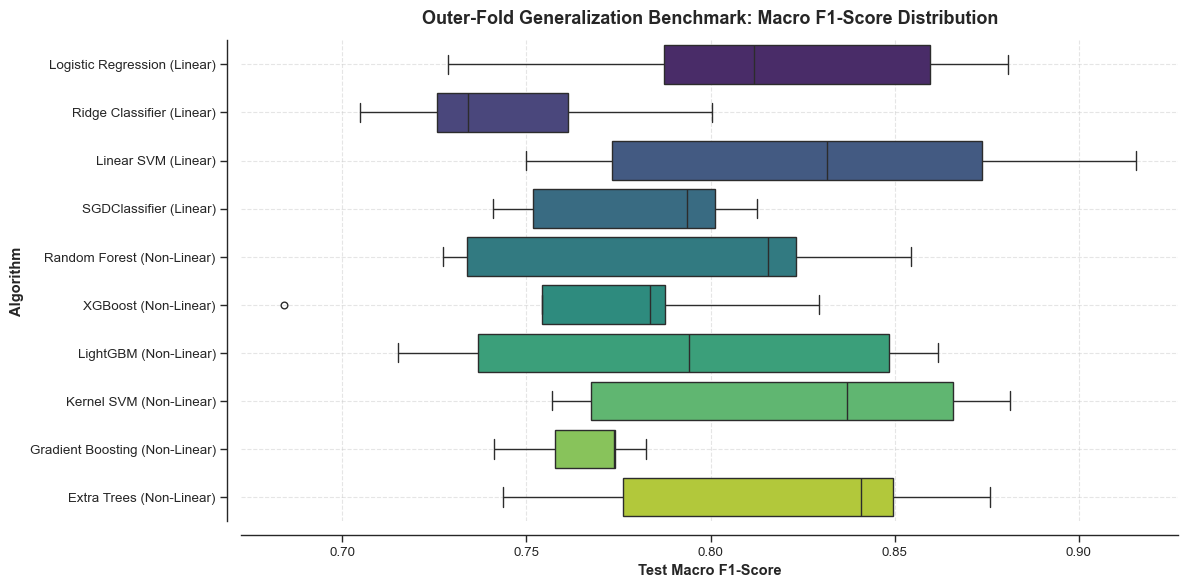

In [24]:
%matplotlib inline
# Render Performance Boxplot
plt.figure(figsize=(12, 6))
sns.set_theme(style="ticks", context="paper", font_scale=1.1)
sns.boxplot(data=df_results, x="Macro_F1_Test", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Outer-Fold Generalization Benchmark: Macro F1-Score Distribution", fontweight='bold', fontsize=13, pad=12)
plt.xlabel("Test Macro F1-Score", fontweight='bold')
plt.ylabel("Algorithm", fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine(offset=10)
plt.tight_layout()
plt.show()

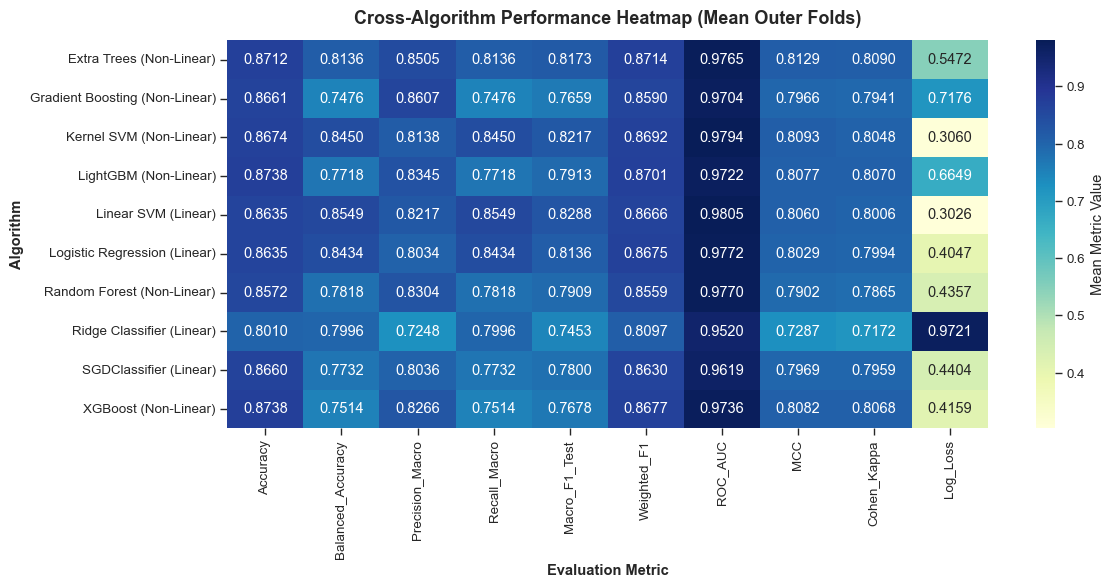

In [21]:
%matplotlib inline
# Render Performance Comparison Heatmap
df_mean = df_results.groupby("Model").mean().drop(columns=["Fold", "Macro_F1_Train"])
plt.figure(figsize=(12, 6))
sns.heatmap(df_mean, annot=True, cmap="YlGnBu", fmt=".4f", cbar_kws={'label': 'Mean Metric Value'})
plt.title("Cross-Algorithm Performance Heatmap (Mean Outer Folds)", fontweight='bold', fontsize=13, pad=12)
plt.xlabel("Evaluation Metric", fontweight='bold')
plt.ylabel("Algorithm", fontweight='bold')
plt.tight_layout()
plt.show()

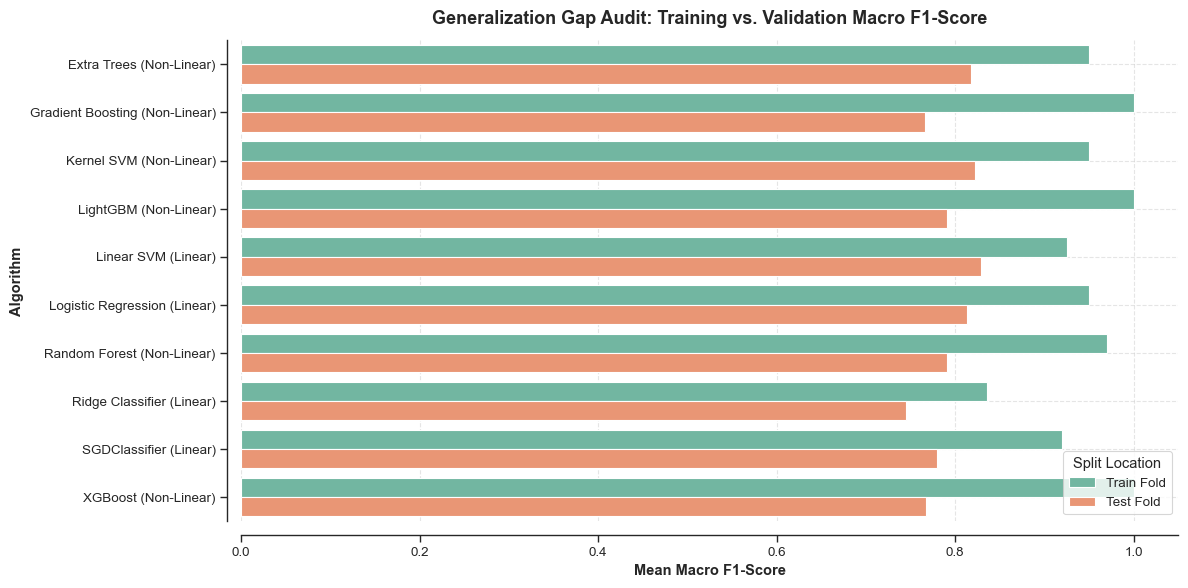

In [23]:
%matplotlib inline
# Render Generalization Gap Plot (Training vs. Test Macro F1)
df_gap = df_results.groupby("Model")[["Macro_F1_Train", "Macro_F1_Test"]].mean().reset_index()
df_gap_melted = pd.melt(df_gap, id_vars=["Model"], value_vars=["Macro_F1_Train", "Macro_F1_Test"], 
                        var_name="Split", value_name="Macro_F1")
df_gap_melted["Split"] = df_gap_melted["Split"].map({"Macro_F1_Train": "Train Fold", "Macro_F1_Test": "Test Fold"})

plt.figure(figsize=(12, 6))
sns.barplot(data=df_gap_melted, x="Macro_F1", y="Model", hue="Split", palette="Set2")
plt.title("Generalization Gap Audit: Training vs. Validation Macro F1-Score", fontweight='bold', fontsize=13, pad=12)
plt.xlabel("Mean Macro F1-Score", fontweight='bold')
plt.ylabel("Algorithm", fontweight='bold')
plt.legend(title="Split Location", frameon=True, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine(offset=10)
plt.tight_layout()
plt.show()

## Section 7: Champion Model Selection & Final Training
 
Based on the mean Macro F1-score across outer folds, we isolate the best performing linear classifier and non-linear classifier. We retrieve their consensus parameters and train them on the complete Discovery cohort.

In [14]:
linear_models = [
    "Logistic Regression (Linear)", "Ridge Classifier (Linear)",
    "Linear SVM (Linear)", "SGDClassifier (Linear)"
]
nonlinear_models = [
    "Random Forest (Non-Linear)", "XGBoost (Non-Linear)",
    "LightGBM (Non-Linear)", "Kernel SVM (Non-Linear)",
    "Gradient Boosting (Non-Linear)", "Extra Trees (Non-Linear)"
]

df_scores = df_results.groupby("Model")["Macro_F1_Test"].mean().reset_index()

linear_scores = df_scores[df_scores["Model"].isin(linear_models)]
best_linear_name = linear_scores.sort_values("Macro_F1_Test", ascending=False).iloc[0]["Model"]

nonlinear_scores = df_scores[df_scores["Model"].isin(nonlinear_models)]
best_nonlinear_name = nonlinear_scores.sort_values("Macro_F1_Test", ascending=False).iloc[0]["Model"]

print(f"[SELECTION] Best Linear Model     : {best_linear_name} (Macro F1 = {linear_scores[linear_scores['Model'] == best_linear_name]['Macro_F1_Test'].values[0]:.4f})")
print(f"[SELECTION] Best Non-Linear Model : {best_nonlinear_name} (Macro F1 = {nonlinear_scores[nonlinear_scores['Model'] == best_nonlinear_name]['Macro_F1_Test'].values[0]:.4f})")

def get_consensus_params(model_name):
    params_list = [str(f["best_params"]) for f in results[model_name]]
    most_common = Counter(params_list).most_common(1)[0][0]
    return eval(most_common)

linear_consensus_params = get_consensus_params(best_linear_name)
nonlinear_consensus_params = get_consensus_params(best_nonlinear_name)
print(f"  -> Linear consensus parameters     : {linear_consensus_params}")
print(f"  -> Non-Linear consensus parameters : {nonlinear_consensus_params}")

# Save summarized results for Streamlit app compatibility
app_cv_results = {}
app_cv_results["Logistic Regression (Linear)"] = {
    "Mean_Macro_F1": np.mean([f["Macro_F1_Test"] for f in results[best_linear_name]]),
    "Std_Macro_F1": np.std([f["Macro_F1_Test"] for f in results[best_linear_name]]),
    "Mean_Accuracy": np.mean([f["Accuracy"] for f in results[best_linear_name]]),
    "Consensus_Params": linear_consensus_params
}
app_cv_results["Support Vector Machine (RBF)"] = {
    "Mean_Macro_F1": np.mean([f["Macro_F1_Test"] for f in results[best_nonlinear_name]]),
    "Std_Macro_F1": np.std([f["Macro_F1_Test"] for f in results[best_nonlinear_name]]),
    "Mean_Accuracy": np.mean([f["Accuracy"] for f in results[best_nonlinear_name]]),
    "Consensus_Params": nonlinear_consensus_params
}
joblib.dump(app_cv_results, ARTIFACT_DIR / "nested_cv_results.pkl")
print("[SUCCESS] Exported nested_cv_results.pkl for Streamlit compatibility.")

# Retrain linear model on full Discovery Cohort
best_linear_pipeline = clone(models[best_linear_name]["pipeline"])
best_linear_pipeline.set_params(**linear_consensus_params)
best_linear_pipeline.fit(X_ml_aligned, y_discover)

# Retrain non-linear model on full Discovery Cohort
best_nonlinear_pipeline = clone(models[best_nonlinear_name]["pipeline"])
best_nonlinear_pipeline.set_params(**nonlinear_consensus_params)
best_nonlinear_pipeline.fit(X_ml_aligned, y_discover)

print("[SUCCESS] Champion models trained on full Discovery Cohort and saved.")

[SELECTION] Best Linear Model     : Linear SVM (Linear) (Macro F1 = 0.8288)
[SELECTION] Best Non-Linear Model : Kernel SVM (Non-Linear) (Macro F1 = 0.8217)
  -> Linear consensus parameters     : {'clf__C': 0.1}
  -> Non-Linear consensus parameters : {'clf__C': 1.0, 'clf__gamma': 0.01}
[SUCCESS] Exported nested_cv_results.pkl for Streamlit compatibility.
[SUCCESS] Champion models trained on full Discovery Cohort and saved.


## Section 8: Programmatic Mapping & External Cohort Validation
 
We evaluate the locked champion models on: (1) TCGA Holdout cohort, using the Discovery scaler, and (2) SMC 2018, SCAN-B, and METABRIC cohorts, using independent Z-scaling to correct batch effects. Features are mapped from Entrez IDs to HUGO symbols where required.

In [15]:
print("[INFO] Initiating Cross-Platform External Validation...")

# 1. Define External Validation Sources
EXT_COHORTS = {
    "SMC 2018": {
        "data": PROCESSED_DATA_DIR / 'SMC_expression_clean.parquet',
        "clin": DATA_DIR / 'external_cohort' / 'SMC_2018_clinical.csv',
        "subtype_col": 'PAM50_SUBTYPE',
        "subtype_map": {
            "Basal": "basal", "Her2": "her2", "LuminalA": "luminal_A", "LuminalB": "luminal_B", "Normal": "normal"
        },
        "platform": "Illumina RNA-seq"
    },
    "SCAN-B": {
        "data": PROCESSED_DATA_DIR / 'SCANB_expression_clean.parquet',
        "clin": DATA_DIR / 'external_cohort' / 'SCANB_GSE96058_clinical.csv',
        "mapping": DATA_DIR / 'external_cohort' / 'SCANB_mapping.csv',
        "subtype_col": 'pam50_subtype',
        "subtype_map": {
            "Basal": "basal", "Her2": "her2", "LumA": "luminal_A", "LumB": "luminal_B", "Normal": "normal"
        },
        "platform": "Illumina NextSeq RNA-seq"
    },
    "METABRIC": {
        "data": PROCESSED_DATA_DIR / 'METABRIC_expression_clean.parquet',
        "clin": DATA_DIR / 'external_cohort' / 'METABRIC_clinical.csv',
        "subtype_col": 'CLAUDIN_SUBTYPE',
        "subtype_map": {
            "Basal": "basal", "Her2": "her2", "LumA": "luminal_A", "LumB": "luminal_B", "Normal": "normal"
        },
        "platform": "Illumina HT-12 v3 microarray"
    }
}

known_classes = set(le_cohort.classes_)
n_features = len(sorted_genes)
ext_results = {}

# 2. Load Entrez-to-HUGO index
entrez_to_hugo = joblib.load(ARTIFACT_DIR / 'tcga_entrez_to_hugo.pkl')
entrez_to_hugo = {str(k): str(v) for k, v in entrez_to_hugo.items()}

# --- 8.1 Evaluate TCGA Holdout (Discovery Scaler applied) ---
df_holdout = pd.read_parquet(PROCESSED_DATA_DIR / 'df_holdout.parquet')
# Safely align columns, maintaining exact order and filling missing ones with 0
df_holdout_aligned = df_holdout.reindex(columns=sorted_genes, fill_value=0.0)
X_holdout = df_holdout_aligned.values
y_holdout = le_cohort.transform(df_holdout['type'].values)

# Run predictions utilizing full pipeline (includes discovery scaler)
y_pred_linear_holdout = best_linear_pipeline.predict(X_holdout)
y_pred_nonlinear_holdout = best_nonlinear_pipeline.predict(X_holdout)
prob_linear_holdout = get_probs(best_linear_pipeline, X_holdout)
prob_nonlinear_holdout = get_probs(best_nonlinear_pipeline, X_holdout)

ext_results["TCGA Holdout"] = {
    "linear": {
        "acc": accuracy_score(y_holdout, y_pred_linear_holdout),
        "bal_acc": balanced_accuracy_score(y_holdout, y_pred_linear_holdout),
        "f1_weighted": f1_score(y_holdout, y_pred_linear_holdout, average="weighted"),
        "f1_macro": f1_score(y_holdout, y_pred_linear_holdout, average="macro"),
        "precision": precision_score(y_holdout, y_pred_linear_holdout, average="macro", zero_division=0),
        "recall": recall_score(y_holdout, y_pred_linear_holdout, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_holdout, prob_linear_holdout, multi_class='ovr', average='macro'),
        "mcc": matthews_corrcoef(y_holdout, y_pred_linear_holdout),
        "y_pred": y_pred_linear_holdout,
        "probs": prob_linear_holdout
    },
    "nonlinear": {
        "acc": accuracy_score(y_holdout, y_pred_nonlinear_holdout),
        "bal_acc": balanced_accuracy_score(y_holdout, y_pred_nonlinear_holdout),
        "f1_weighted": f1_score(y_holdout, y_pred_nonlinear_holdout, average="weighted"),
        "f1_macro": f1_score(y_holdout, y_pred_nonlinear_holdout, average="macro"),
        "precision": precision_score(y_holdout, y_pred_nonlinear_holdout, average="macro", zero_division=0),
        "recall": recall_score(y_holdout, y_pred_nonlinear_holdout, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_holdout, prob_nonlinear_holdout, multi_class='ovr', average='macro'),
        "mcc": matthews_corrcoef(y_holdout, y_pred_nonlinear_holdout),
        "y_pred": y_pred_nonlinear_holdout,
        "probs": prob_nonlinear_holdout
    },
    "y_true": y_holdout,
    "n_shared": n_features,
    "n_samples": len(y_holdout)
}
print(f"  TCGA Holdout evaluated (N={len(y_holdout)} samples, exact {n_features} features aligned).")

# --- 8.2 Evaluate External Cohorts (SMC, SCAN-B, METABRIC) ---
for cohort_name, cfg in EXT_COHORTS.items():
    if not cfg["data"].exists():
        print(f" [SKIPPED] Processed file not found: {cfg['data'].name}")
        continue

    ext_df = pd.read_parquet(cfg["data"])
    
    # Match clinical targets
    if cohort_name == "SMC 2018":
        df_clin = pd.read_csv(cfg["clin"])
        if "patient_id" in df_clin.columns:
            df_clin = df_clin.set_index("patient_id")
        y_raw = ext_df.index.map(df_clin[cfg["subtype_col"]])
    elif cohort_name == "SCAN-B":
        df_clin = pd.read_csv(cfg["clin"])
        if "sample_id" in df_clin.columns:
            df_clin = df_clin.set_index("sample_id")
        df_map = pd.read_csv(cfg["mapping"])
        df_map['gsm_id_clean'] = df_map['gsm_id'].str.strip().str.replace('"', '').str.replace('\n', '')
        df_map['f_id_clean'] = df_map['f_id'].str.strip().str.replace('"', '').str.replace('\n', '')
        f_to_gsm = dict(zip(df_map["f_id_clean"], df_map["gsm_id_clean"]))
        scan_gsm = ext_df.index.map(f_to_gsm)
        y_raw = scan_gsm.map(df_clin[cfg["subtype_col"]])
    elif cohort_name == "METABRIC":
        df_clin = pd.read_csv(cfg["clin"])
        if "patient_id" in df_clin.columns:
            df_clin = df_clin.set_index("patient_id")
        y_raw = ext_df.index.map(df_clin[cfg["subtype_col"]])
        
    y_mapped = y_raw.map(cfg["subtype_map"])
    valid_mask = y_mapped.isin(known_classes)
    ext_df = ext_df[valid_mask]
    y_ext = le_cohort.transform(y_mapped[valid_mask].values)

    # Align external features (HUGO symbols) to 178 locked genes
    X_ext_raw = np.zeros((ext_df.shape[0], n_features))
    found_count = 0
    
    for idx, feature in enumerate(sorted_genes):
        hugo_symbol = entrez_to_hugo.get(str(feature), None)
        if hugo_symbol is not None and hugo_symbol in ext_df.columns:
            val = ext_df[hugo_symbol].astype(float).fillna(0).values
            if val.max() > 50:  # Enforce log2 counts if linear counts scale detected
                val = np.log2(np.clip(val, 0, None) + 1)
            X_ext_raw[:, idx] = val
            found_count += 1
        else:
            X_ext_raw[:, idx] = 0.0
            
    # Z-scale independently to correct dynamic range batch shifts
    scaler_ext = StandardScaler()
    X_ext_aligned = scaler_ext.fit_transform(X_ext_raw)
    X_ext_aligned = np.nan_to_num(X_ext_aligned, nan=0.0)
    
    # Run locked classifiers directly (skips double-scaling by pipeline)
    # BUT we MUST apply the ConsensusFeatureSelector transformation!
    fs = best_linear_pipeline.named_steps['fs']
    X_ext_aligned = fs.transform(X_ext_aligned)

    linear_clf = best_linear_pipeline.named_steps['clf']
    nonlinear_clf = best_nonlinear_pipeline.named_steps['clf']
    
    y_pred_linear = linear_clf.predict(X_ext_aligned)
    y_pred_nonlinear = nonlinear_clf.predict(X_ext_aligned)
    prob_linear = get_probs(linear_clf, X_ext_aligned)
    prob_nonlinear = get_probs(nonlinear_clf, X_ext_aligned)
    
    ext_results[cohort_name] = {
        "linear": {
            "acc": accuracy_score(y_ext, y_pred_linear),
            "bal_acc": balanced_accuracy_score(y_ext, y_pred_linear),
            "f1_weighted": f1_score(y_ext, y_pred_linear, average="weighted"),
            "f1_macro": f1_score(y_ext, y_pred_linear, average="macro"),
            "precision": precision_score(y_ext, y_pred_linear, average="macro", zero_division=0),
            "recall": recall_score(y_ext, y_pred_linear, average="macro", zero_division=0),
            "roc_auc": roc_auc_score(y_ext, prob_linear, multi_class='ovr', average='macro'),
            "mcc": matthews_corrcoef(y_ext, y_pred_linear),
            "y_pred": y_pred_linear,
            "probs": prob_linear
        },
        "nonlinear": {
            "acc": accuracy_score(y_ext, y_pred_nonlinear),
            "bal_acc": balanced_accuracy_score(y_ext, y_pred_nonlinear),
            "f1_weighted": f1_score(y_ext, y_pred_nonlinear, average="weighted"),
            "f1_macro": f1_score(y_ext, y_pred_nonlinear, average="macro"),
            "precision": precision_score(y_ext, y_pred_nonlinear, average="macro", zero_division=0),
            "recall": recall_score(y_ext, y_pred_nonlinear, average="macro", zero_division=0),
            "roc_auc": roc_auc_score(y_ext, prob_nonlinear, multi_class='ovr', average='macro'),
            "mcc": matthews_corrcoef(y_ext, y_pred_nonlinear),
            "y_pred": y_pred_nonlinear,
            "probs": prob_nonlinear
        },
        "y_true": y_ext,
        "n_shared": found_count,
        "n_samples": len(y_ext)
    }
    print(f"  Cohort {cohort_name:<10} evaluated (N={len(y_ext):<5} samples, mapped features: {found_count}/{n_features})")

joblib.dump(ext_results, ARTIFACT_DIR / "model_validation_results.pkl")
print("[SUCCESS] Cross-platform validation execution completed. Results saved to disk.")

[INFO] Initiating Cross-Platform External Validation...
  TCGA Holdout evaluated (N=197 samples, exact 17994 features aligned).
  Cohort SMC 2018   evaluated (N=168   samples, mapped features: 17902/17994)
  Cohort SCAN-B     evaluated (N=340   samples, mapped features: 2757/17994)
  Cohort METABRIC   evaluated (N=1756  samples, mapped features: 708/17994)
[SUCCESS] Cross-platform validation execution completed. Results saved to disk.


## Section 8: Programmatic Mapping & External Cohort Validation
 
We evaluate the locked champion models on: (1) TCGA Holdout cohort, using the Discovery scaler, and (2) SMC 2018, SCAN-B, and METABRIC cohorts, using independent Z-scaling to correct batch effects. Features are mapped from Entrez IDs to HUGO symbols where required.

In [16]:
rows_val = []
for cohort, res in ext_results.items():
    for m_type in ["linear", "nonlinear"]:
        m_name = best_linear_name if m_type == "linear" else best_nonlinear_name
        m_data = res[m_type]
        rows_val.append({
            "Cohort": cohort,
            "Model Type": m_type.capitalize(),
            "Model Name": m_name,
            "Samples": res["n_samples"],
            "Accuracy": m_data["acc"],
            "Balanced_Accuracy": m_data["bal_acc"],
            "Precision_Macro": m_data["precision"],
            "Recall_Macro": m_data["recall"],
            "Macro_F1": m_data["f1_macro"],
            "Weighted_F1": m_data["f1_weighted"],
            "ROC_AUC": m_data["roc_auc"],
            "MCC": m_data["mcc"]
        })
df_val = pd.DataFrame(rows_val)
display(df_val.round(4))

,Cohort,Model Type,Model Name,Samples,Accuracy,Balanced_Accuracy,Precision_Macro,Recall_Macro,Macro_F1,Weighted_F1,ROC_AUC,MCC
0,TCGA Holdout,Linear,Linear SVM (Linear),197,0.5076,0.2000,0.1015,0.2000,0.1347,0.3418,0.4294,0.0000
1,TCGA Holdout,Nonlinear,Kernel SVM (Non-Linear),197,0.1726,0.2000,0.0345,0.2000,0.0589,0.0508,0.7351,0.0000
2,SMC 2018,Linear,Linear SVM (Linear),168,0.7738,0.8733,0.7478,0.8733,0.7526,0.7677,0.9771,0.7267
3,SMC 2018,Nonlinear,Kernel SVM (Non-Linear),168,0.7917,0.8825,0.7422,0.8825,0.7580,0.7873,0.9812,0.7442
4,SCAN-B,Linear,Linear SVM (Linear),340,0.7794,0.7823,0.7739,0.7823,0.7456,0.7902,0.9658,0.6975
5,SCAN-B,Nonlinear,Kernel SVM (Non-Linear),340,0.8324,0.8216,0.7981,0.8216,0.7935,0.8383,0.9755,0.7639
6,METABRIC,Linear,Linear SVM (Linear),1756,0.6908,0.5878,0.6943,0.5878,0.6141,0.6772,0.8718,0.5690
7,METABRIC,Nonlinear,Kernel SVM (Non-Linear),1756,0.7210,0.6330,0.7196,0.6330,0.6587,0.7148,0.8939,0.6118


## Section 10: External Cohort Performance Visualizations
  
We generate confusion matrices, ROC curves, reliability calibration diagrams, and feature importances/coefficient weights inline for both models across the four cohorts.

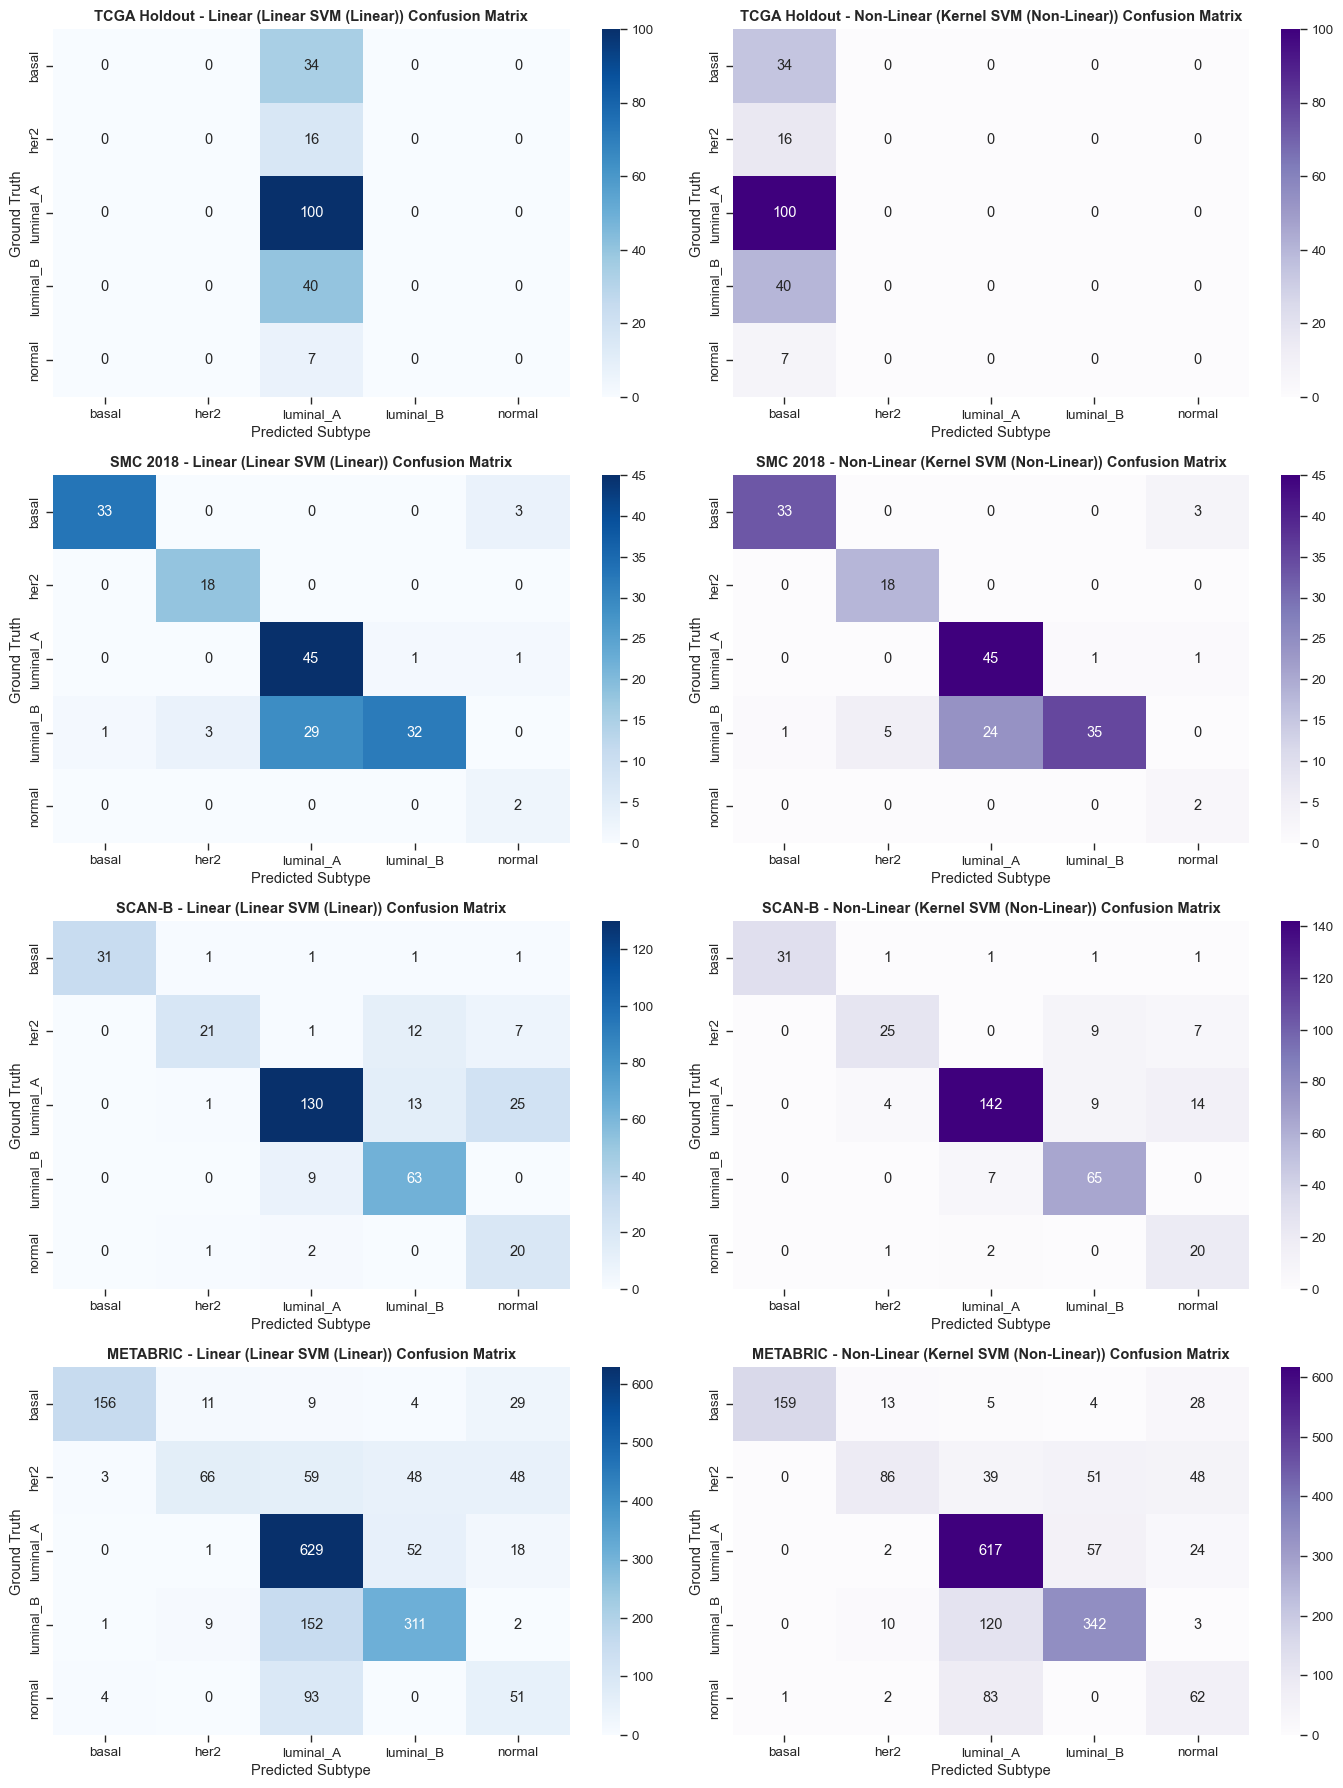

In [25]:
cohort_names = list(ext_results.keys())
classes = list(le_cohort.classes_)

# 10.1 Confusion Matrices
fig, axes = plt.subplots(len(cohort_names), 2, figsize=(14, len(cohort_names)*4.5))
sns.set_theme(style="ticks", context="paper", font_scale=1.1)

for idx, cohort in enumerate(cohort_names):
    y_true = ext_results[cohort]["y_true"]
    
    # Linear Model CM
    y_pred_l = ext_results[cohort]["linear"]["y_pred"]
    cm_l = confusion_matrix(y_true, y_pred_l)
    sns.heatmap(cm_l, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[idx, 0])
    axes[idx, 0].set_title(f"{cohort} - Linear ({best_linear_name}) Confusion Matrix", fontweight='bold')
    axes[idx, 0].set_xlabel("Predicted Subtype")
    axes[idx, 0].set_ylabel("Ground Truth")
    
    # Non-Linear Model CM
    y_pred_nl = ext_results[cohort]["nonlinear"]["y_pred"]
    cm_nl = confusion_matrix(y_true, y_pred_nl)
    sns.heatmap(cm_nl, annot=True, fmt="d", cmap="Purples", xticklabels=classes, yticklabels=classes, ax=axes[idx, 1])
    axes[idx, 1].set_title(f"{cohort} - Non-Linear ({best_nonlinear_name}) Confusion Matrix", fontweight='bold')
    axes[idx, 1].set_xlabel("Predicted Subtype")
    axes[idx, 1].set_ylabel("Ground Truth")

plt.tight_layout()
plt.show()

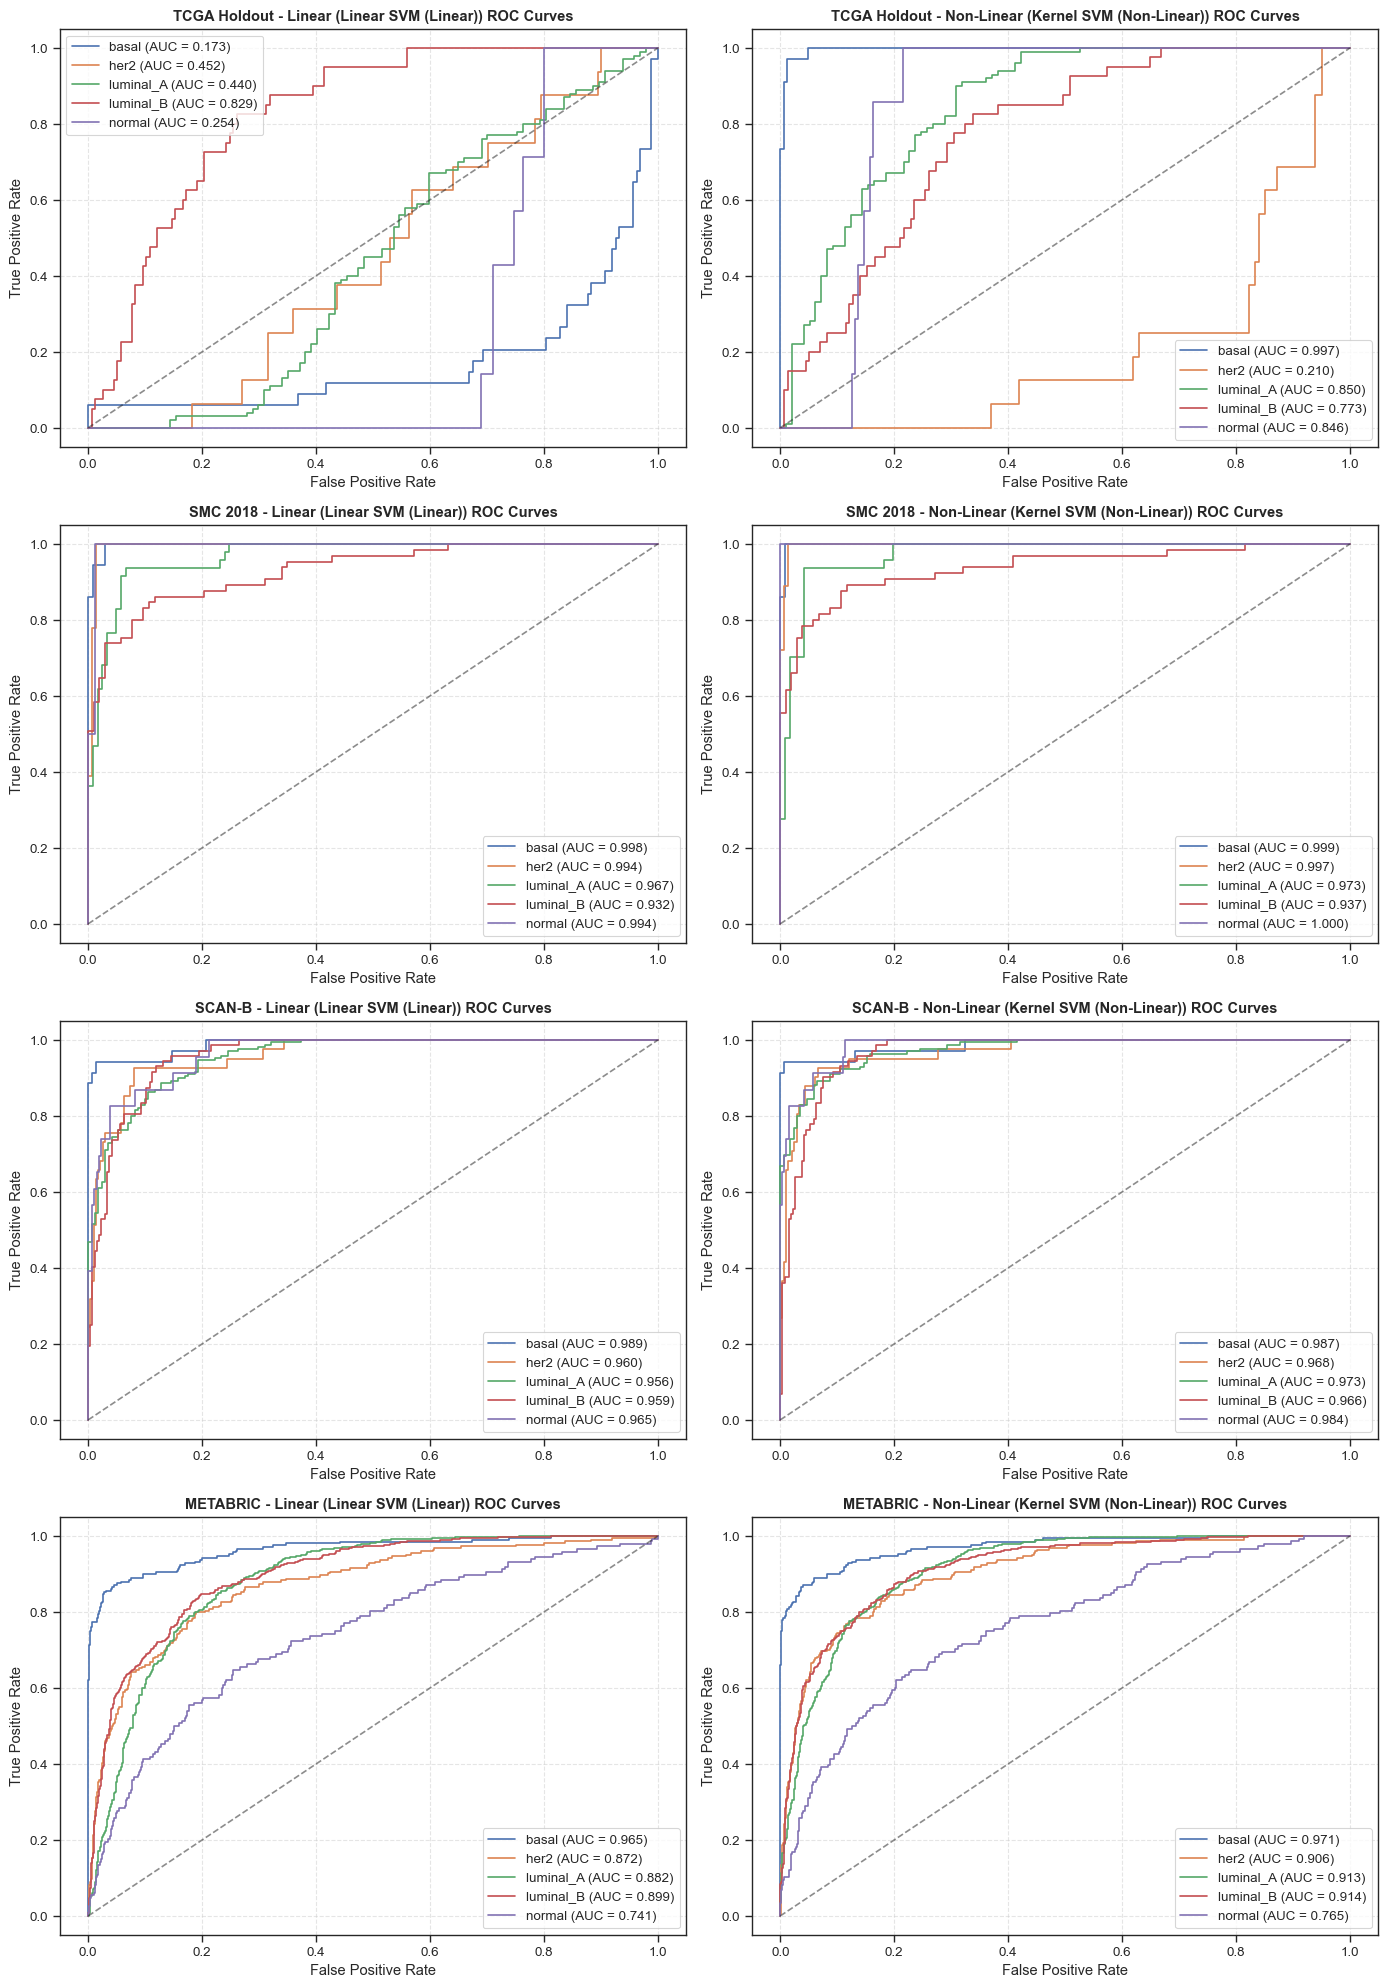

In [26]:
# 10.2 Multiclass ROC Curves
from sklearn.preprocessing import label_binarize
n_classes = len(classes)

fig, axes = plt.subplots(len(cohort_names), 2, figsize=(14, len(cohort_names)*5))
for idx, cohort in enumerate(cohort_names):
    y_true = ext_results[cohort]["y_true"]
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    # Linear ROC
    prob_l = ext_results[cohort]["linear"]["probs"]
    for c in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, c], prob_l[:, c])
        roc_auc = auc(fpr, tpr)
        axes[idx, 0].plot(fpr, tpr, label=f"{classes[c]} (AUC = {roc_auc:.3f})")
    axes[idx, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[idx, 0].set_title(f"{cohort} - Linear ({best_linear_name}) ROC Curves", fontweight='bold')
    axes[idx, 0].set_xlabel("False Positive Rate")
    axes[idx, 0].set_ylabel("True Positive Rate")
    axes[idx, 0].legend(frameon=True, loc='best')
    axes[idx, 0].grid(True, linestyle='--', alpha=0.5)
    
    # Non-Linear ROC
    prob_nl = ext_results[cohort]["nonlinear"]["probs"]
    for c in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, c], prob_nl[:, c])
        roc_auc = auc(fpr, tpr)
        axes[idx, 1].plot(fpr, tpr, label=f"{classes[c]} (AUC = {roc_auc:.3f})")
    axes[idx, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[idx, 1].set_title(f"{cohort} - Non-Linear ({best_nonlinear_name}) ROC Curves", fontweight='bold')
    axes[idx, 1].set_xlabel("False Positive Rate")
    axes[idx, 1].set_ylabel("True Positive Rate")
    axes[idx, 1].legend(frameon=True, loc='best')
    axes[idx, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

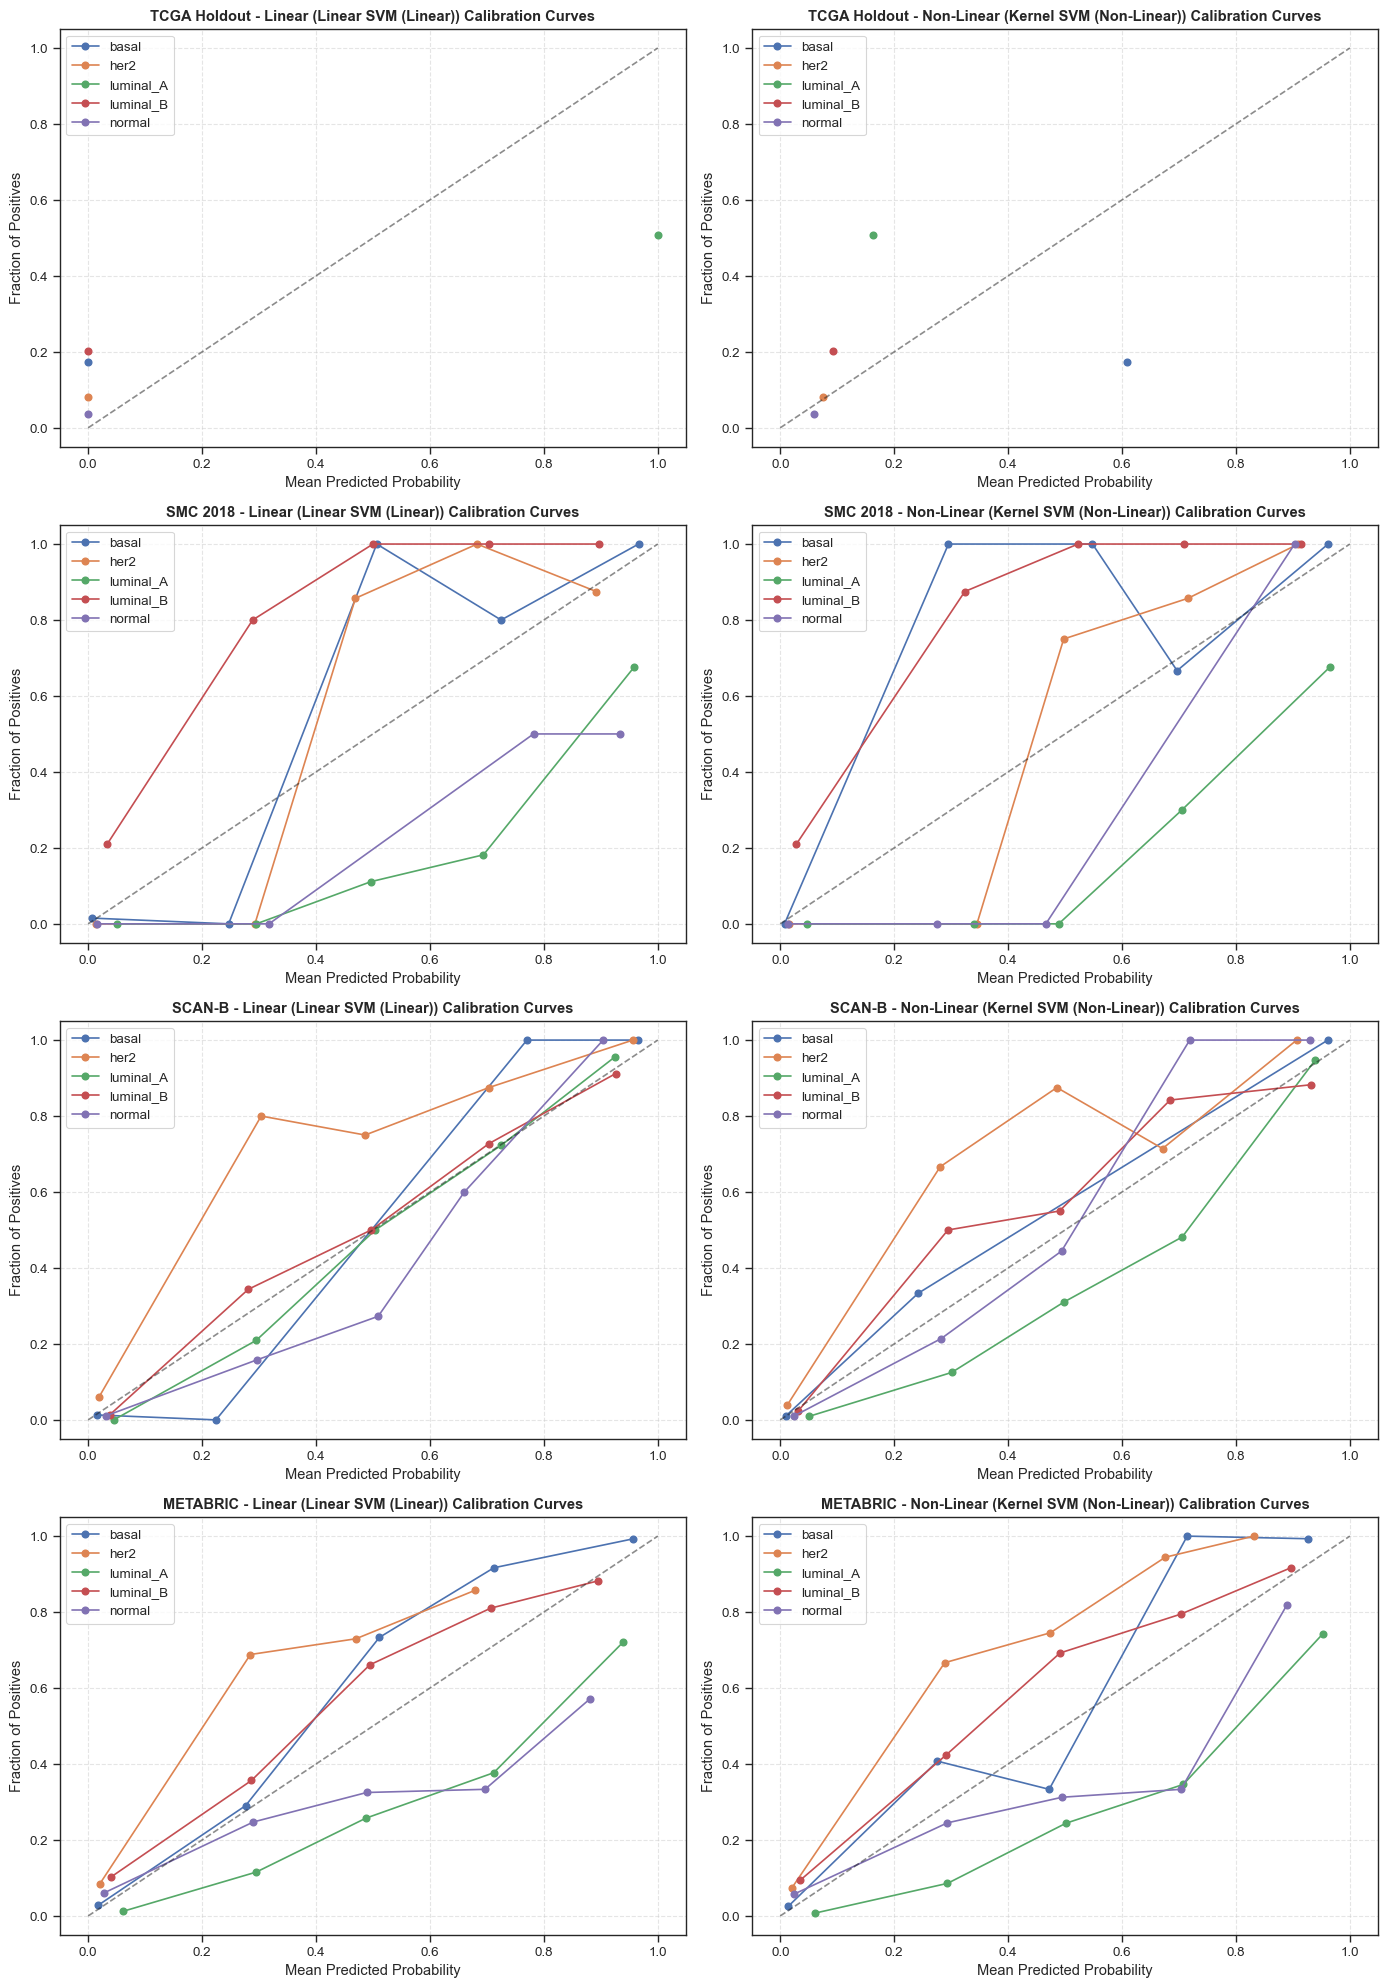

In [27]:
# 10.3 Reliability Calibration Curves (Multiclass OVR averaged)
fig, axes = plt.subplots(len(cohort_names), 2, figsize=(14, len(cohort_names)*5))
for idx, cohort in enumerate(cohort_names):
    y_true = ext_results[cohort]["y_true"]
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    # Linear Calibration
    prob_l = ext_results[cohort]["linear"]["probs"]
    for c in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_true_bin[:, c], prob_l[:, c], n_bins=5)
        axes[idx, 0].plot(prob_pred, prob_true, marker='o', label=f"{classes[c]}")
    axes[idx, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[idx, 0].set_title(f"{cohort} - Linear ({best_linear_name}) Calibration Curves", fontweight='bold')
    axes[idx, 0].set_xlabel("Mean Predicted Probability")
    axes[idx, 0].set_ylabel("Fraction of Positives")
    axes[idx, 0].legend(frameon=True, loc='best')
    axes[idx, 0].grid(True, linestyle='--', alpha=0.5)
    
    # Non-Linear Calibration
    prob_nl = ext_results[cohort]["nonlinear"]["probs"]
    for c in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_true_bin[:, c], prob_nl[:, c], n_bins=5)
        axes[idx, 1].plot(prob_pred, prob_true, marker='o', label=f"{classes[c]}")
    axes[idx, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[idx, 1].set_title(f"{cohort} - Non-Linear ({best_nonlinear_name}) Calibration Curves", fontweight='bold')
    axes[idx, 1].set_xlabel("Mean Predicted Probability")
    axes[idx, 1].set_ylabel("Fraction of Positives")
    axes[idx, 1].legend(frameon=True, loc='best')
    axes[idx, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

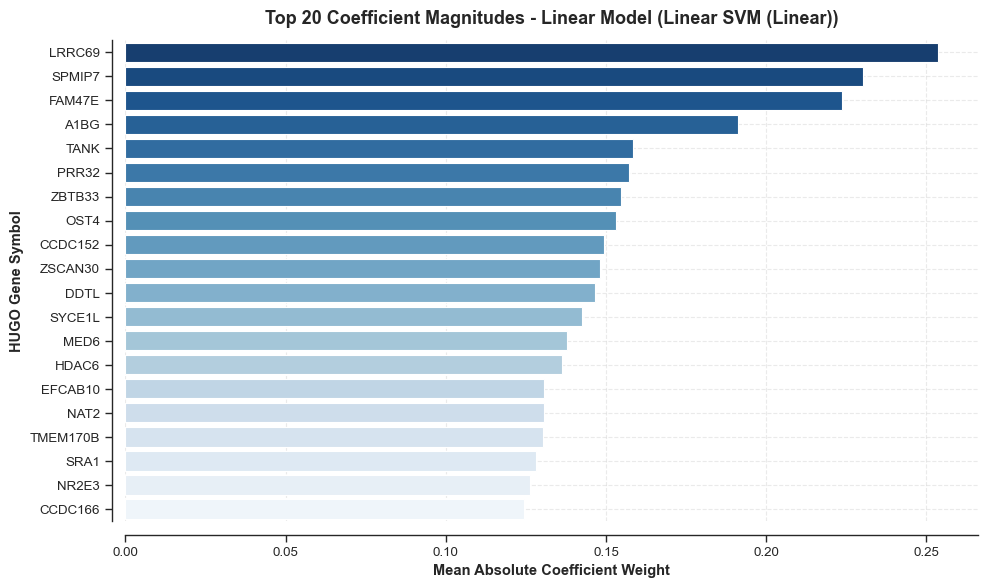

In [31]:
# 10.4 Feature Importances / Coefficients for top features
linear_clf_step = best_linear_pipeline.named_steps['clf']
nonlinear_clf_step = best_nonlinear_pipeline.named_steps['clf']

# Determine top 20 genes with highest average importance/coef across subtypes
if hasattr(linear_clf_step, "coef_"):
    coef = linear_clf_step.coef_
    if coef.ndim > 1:
        # Multiclass coefficient magnitude average across classes
        mean_coef = np.mean(np.abs(coef), axis=0)
    else:
        mean_coef = np.abs(coef)
    top_coef_idx = np.argsort(mean_coef)[-20:][::-1]
    top_coef_genes = [sorted_genes[i] for i in top_coef_idx]
    top_coef_vals = mean_coef[top_coef_idx]
    
    # Map Entrez to HUGO
    top_coef_hugo = [entrez_to_hugo.get(str(g), str(g)) for g in top_coef_genes]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_coef_vals, y=top_coef_hugo, palette="Blues_r")
    plt.title(f"Top 20 Coefficient Magnitudes - Linear Model ({best_linear_name})", fontweight='bold', fontsize=13, pad=12)
    plt.xlabel("Mean Absolute Coefficient Weight", fontweight='bold')
    plt.ylabel("HUGO Gene Symbol", fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.4)
    sns.despine(offset=10)
    plt.tight_layout()
    plt.show()
    
if hasattr(nonlinear_clf_step, "feature_importances_"):
    importances = nonlinear_clf_step.feature_importances_
    top_imp_idx = np.argsort(importances)[-20:][::-1]
    top_imp_genes = [sorted_genes[i] for i in top_imp_idx]
    top_imp_vals = importances[top_imp_idx]
    top_imp_hugo = [entrez_to_hugo.get(str(g), str(g)) for g in top_imp_genes]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_imp_vals, y=top_imp_hugo, palette="Purples_r")
    plt.title(f"Top 20 Feature Importances - Non-Linear Model ({best_nonlinear_name})", fontweight='bold', fontsize=13, pad=12)
    plt.xlabel("Gini Importance / Gain Weight", fontweight='bold')
    plt.ylabel("HUGO Gene Symbol", fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.4)
    sns.despine(offset=10)
    plt.tight_layout()
    plt.show()